In [1]:
!pip3 install osmnx
!pip3 install networkx



In [2]:
import networkx as nx
import osmnx as ox
import ipywidgets as widgets
from IPython.display import display
import numpy as np
import geopandas as gpd
from shapely.geometry import box


In [3]:
# ============================================
# 1. Distritos de Sevilla y coordenadas aproximadas
# ============================================

distritos_sevilla = {
    "Casco Antiguo": (37.3925, -5.9935),
    "Macarena": (37.4100, -5.9800),
    "Nervión": (37.3830, -5.9730),
    "San Pablo – Santa Justa": (37.3920, -5.9640),
    "Cerro-Amate": (37.3720, -5.9410),
    "Sur": (37.3680, -5.9860),
    "Triana": (37.3820, -6.0100),
    "Los Remedios": (37.3770, -6.0070),
    "Bellavista – La Palmera": (37.3380, -5.9800),
    "Este – Alcosa – Torreblanca": (37.4000, -5.9200),
    "Norte": (37.4200, -5.9800)
}

In [4]:
# ============================================
# 2. Selector de distrito (Google Colab)
# ============================================

selector = widgets.Dropdown(
    options=list(distritos_sevilla.keys()),
    description='Distrito:',
    value="Nervión"
)

display(selector)

print("Seleccione un distrito en el menú desplegable y ejecute la siguiente celda.")

Dropdown(description='Distrito:', index=2, options=('Casco Antiguo', 'Macarena', 'Nervión', 'San Pablo – Santa…

Seleccione un distrito en el menú desplegable y ejecute la siguiente celda.


In [5]:
# Obtener el distrito seleccionado
nombre_distrito = selector.value
coords = distritos_sevilla[nombre_distrito]

print(f"✔ Distrito seleccionado: {nombre_distrito}")
print(f"  Coordenadas aproximadas: {coords}")

# ============================================
# 3. Descargar red viaria desde OSM
# ============================================

G = ox.graph.graph_from_point(
    coords,
    dist=750,
    network_type="drive"
)

✔ Distrito seleccionado: Nervión
  Coordenadas aproximadas: (37.383, -5.973)


In [6]:
# ============================================
# 4. Calcular velocidades y tiempos de viaje
# ============================================

G = ox.routing.add_edge_speeds(G)
G = ox.routing.add_edge_travel_times(G)


In [7]:
# ============================================
# 5. Convertir a GeoDataFrames y volver a grafo
# ============================================

gdf_nodes, gdf_edges = ox.convert.graph_to_gdfs(G)
G = ox.convert.graph_from_gdfs(gdf_nodes, gdf_edges, graph_attrs=G.graph)



In [8]:
# ============================================
# 6. Convertir a DiGraph para centralidad
# ============================================

D = ox.convert.to_digraph(G, weight="travel_time")


In [9]:
# ============================================
# 7. Calcular betweenness centrality
# ============================================

bc = nx.betweenness_centrality(D, weight="travel_time", normalized=True)
nx.set_node_attributes(G, values=bc, name="bc")



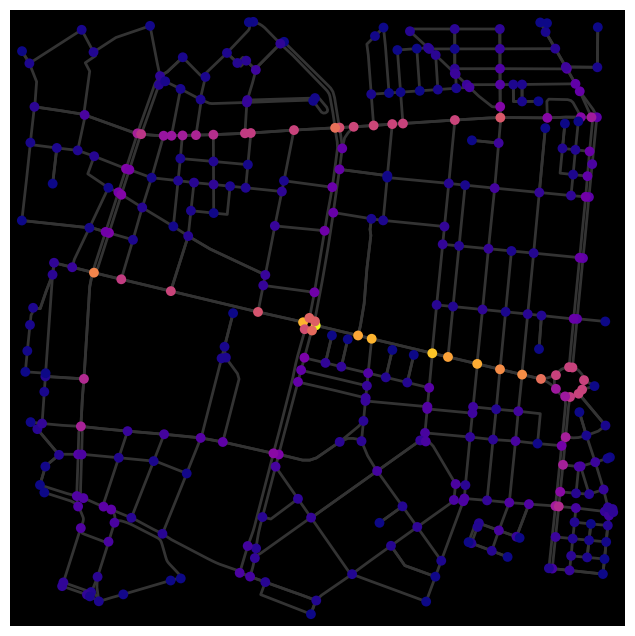

In [10]:
# ============================================
# 8. Plot coloreado por centralidad
# ============================================

nc = ox.plot.get_node_colors_by_attr(G, "bc", cmap="plasma")
fig, ax = ox.plot.plot_graph(
    G,
    bgcolor="k",
    node_color=nc,
    node_size=50,
    edge_linewidth=2,
    edge_color="#333333"
)

In [11]:

# ============================================
# 9. Guardar resultados
# ============================================

ox.io.save_graph_geopackage(G, filepath="./graph.gpkg")
ox.io.save_graphml(G, filepath="./graph.graphml")

print("\n✔ Archivos guardados: graph.gpkg y graph.graphml")



✔ Archivos guardados: graph.gpkg y graph.graphml


In [12]:


# Usamos los edges del grafo ya generado
edges = gdf_edges.to_crs(epsg=3857)  # trabajar en metros

# ============================================
# 1. Crear bounding box y cuadrícula
# ============================================

minx, miny, maxx, maxy = edges.total_bounds

N = 50  # resolución de la matriz
dx = (maxx - minx) / N
dy = (maxy - miny) / N

grid = []
for i in range(N):
    for j in range(N):
        cell = box(minx + j*dx, miny + i*dy,
                   minx + (j+1)*dx, miny + (i+1)*dy)
        grid.append(cell)

gdf_grid = gpd.GeoDataFrame(geometry=grid, crs="EPSG:3857")

# ============================================
# 2. Intersección: ¿hay carretera en la celda?
# ============================================
# Intersección celda–carretera
intersects = gpd.sjoin(gdf_grid, edges, how="left", predicate="intersects")

# Marcamos si hay carretera
intersects["is_road"] = ~intersects["u"].isna()

# Agrupar por celda original (cada celda aparece varias veces)
grouped = intersects.groupby(intersects.index)["is_road"].max()

# Convertir a matriz NxN
road_matrix = grouped.values.reshape(N, N)


np.save("/content/road_matrix.npy", road_matrix)


FileNotFoundError: [Errno 2] No such file or directory: '/content/road_matrix.npy'